# CellChat Chord Diagram Figures
Minimal reproducible code to generate:
- `Upregulated_signaling_in_Expanded.svg`
- `Downregulated_signaling_in_Expanded.svg`
- `Upregulated_signaling_in_Basal_to_Fibroblasts.svg`
- `Downregulated_signaling_in_Basal_to_Fibroblasts.svg`

## Step 1: Load libraries, subset data & run CellChat pipeline

In [1]:
library(Seurat)
library(CellChat)
library(patchwork)
options(stringsAsFactors = FALSE)
library(future)

Warning message:
“package ‘Seurat’ was built under R version 4.3.2”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.3.2”
Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.3.2”
‘SeuratObject’ was built with package ‘Matrix’ 1.6.3 but the current
version is 1.6.5; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed


Attaching package: ‘SeuratObject’


The following object is masked from ‘package:base’:

    intersect


Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: igraph


Attaching package: ‘igraph’


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following object is masked from ‘package:Seu

In [2]:
sessionInfo()

R version 4.3.1 (2023-06-16)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Rocky Linux 9.6 (Blue Onyx)

Matrix products: default
BLAS/LAPACK: /vsc-hard-mounts/leuven-data/337/vsc33740/miniforge3/envs/CellChat_R/lib/libopenblasp-r0.3.26.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Brussels
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] future_1.34.0       patchwork_1.3.0     CellChat_2.1.2     
 [4] Biobase_2.62.0      BiocGenerics_0.48.1 ggplot2_3.5.1      
 [7] igraph_2.1.1        dplyr_1.1.4         Seura

In [ ]:


target_groups <- c("Fibroblast 4", "keratinocytes_basal")

subset_cellchat_groups <- function(cellchat, groups) {
  meta <- cellchat@meta
  labels <- as.character(cellchat@idents)
  cells.use <- rownames(meta)[labels %in% groups]
  if (length(cells.use) == 0) stop("No cells found for requested groups.")

  cellchat@data <- cellchat@data[, cells.use, drop = FALSE]
  cellchat@meta <- meta[cells.use, , drop = FALSE]

  if (!is.null(dim(cellchat@data.signaling))) {
    cols.keep <- intersect(colnames(cellchat@data.signaling), cells.use)
    cellchat@data.signaling <- cellchat@data.signaling[, cols.keep, drop = FALSE]
  }

  new_labels <- labels[labels %in% groups]
  cellchat@idents <- droplevels(factor(new_labels, levels = groups))

  if (!is.null(cellchat@var.features)) {
    cellchat@var.features <- intersect(cellchat@var.features, rownames(cellchat@data))
  }

  cellchat@LR   <- list()
  cellchat@net  <- list(size = as.numeric(table(cellchat@idents)))
  names(cellchat@net$size) <- names(table(cellchat@idents))
  cellchat@netP <- list()

  cellchat
}

# --- Load base objects ---
cellchat_expanded <- readRDS("skin_expansion_data/cellchat_expanded_clean_base.rds")
cellchat_control  <- readRDS("skin_expansion_data/cellchat_control_clean_base.rds")

# --- Subset to target groups ---
cellchat_control_sub  <- subset_cellchat_groups(cellchat_control,  target_groups)
cellchat_expanded_sub <- subset_cellchat_groups(cellchat_expanded, target_groups)

# --- Run pipeline ---
options(future.globals.maxSize = 60 * 1024^3)
future::plan("multisession", workers = 12)

# Control
cellchat_control_sub <- subsetData(cellchat_control_sub)
cellchat_control_sub <- identifyOverExpressedGenes(cellchat_control_sub)
cellchat_control_sub <- identifyOverExpressedInteractions(cellchat_control_sub)
cellchat_control_sub <- computeCommunProb(cellchat_control_sub, type = "triMean")
cellchat_control_sub <- filterCommunication(cellchat_control_sub, min.cells = 10)
cellchat_control_sub <- computeCommunProbPathway(cellchat_control_sub)
cellchat_control_sub <- aggregateNet(cellchat_control_sub)
cellchat_control_sub <- netAnalysis_computeCentrality(cellchat_control_sub)

# Expanded
cellchat_expanded_sub <- subsetData(cellchat_expanded_sub)
cellchat_expanded_sub <- identifyOverExpressedGenes(cellchat_expanded_sub)
cellchat_expanded_sub <- identifyOverExpressedInteractions(cellchat_expanded_sub)
cellchat_expanded_sub <- computeCommunProb(cellchat_expanded_sub, type = "triMean")
cellchat_expanded_sub <- filterCommunication(cellchat_expanded_sub, min.cells = 10)
cellchat_expanded_sub <- computeCommunProbPathway(cellchat_expanded_sub)
cellchat_expanded_sub <- aggregateNet(cellchat_expanded_sub)
cellchat_expanded_sub <- netAnalysis_computeCentrality(cellchat_expanded_sub)

# --- Save processed objects (run once, then use the load cell below) ---
saveRDS(cellchat_control_sub,  "skin_expansion_data/cellchat_control_sub_processed.rds")
saveRDS(cellchat_expanded_sub, "skin_expansion_data/cellchat_expanded_sub_processed.rds")
message("Saved processed objects to skin_expansion_data/")

## Step 1b: (Alternative) Load pre-computed objects — skip Step 1 if already saved

In [2]:
library(CellChat)

# Load the pre-computed processed objects (skips the full pipeline above)
cellchat_control_sub  <- readRDS("skin_expansion_data/cellchat_control_fibro4_kera_sub.rds")
cellchat_expanded_sub <- readRDS("skin_expansion_data/cellchat_expanded_fibro4_kera_sub.rds")
message("Loaded pre-computed objects successfully.")

Loaded pre-computed objects successfully.



## Step 2: Merge objects & identify differentially expressed LR pairs

In [3]:
object.list <- list(Control = cellchat_control_sub, Expanded = cellchat_expanded_sub)
cellchat    <- mergeCellChat(object.list, add.names = names(object.list))

# Differential expression analysis (Expanded vs Control)
pos.dataset   <- "Expanded"
features.name <- paste0(pos.dataset, ".merged")

cellchat <- identifyOverExpressedGenes(
  cellchat,
  group.dataset    = "datasets",
  pos.dataset      = pos.dataset,
  features.name    = features.name,
  only.pos         = FALSE,
  thresh.pc        = 0.1,
  thresh.fc        = 0.05,
  thresh.p         = 0.05,
  group.DE.combined = FALSE
)
net      <- netMappingDEG(cellchat, features.name = features.name, variable.all = TRUE)
net.up   <- subsetCommunication(cellchat, net = net, datasets = "Expanded", ligand.logFC =  0.05, receptor.logFC = NULL)
net.down <- subsetCommunication(cellchat, net = net, datasets = "Control",  ligand.logFC = -0.05, receptor.logFC = NULL)

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Use the joint cell labels from the merged CellChat object



In [15]:
write.csv(net.up,'skin_expansion_cellchat/net_up_for_chordplot.csv')
write.csv(net.down,'skin_expansion_cellchat/net_down__for_chordplot.csv')

## Step 3: Draw chord diagrams & save SVGs

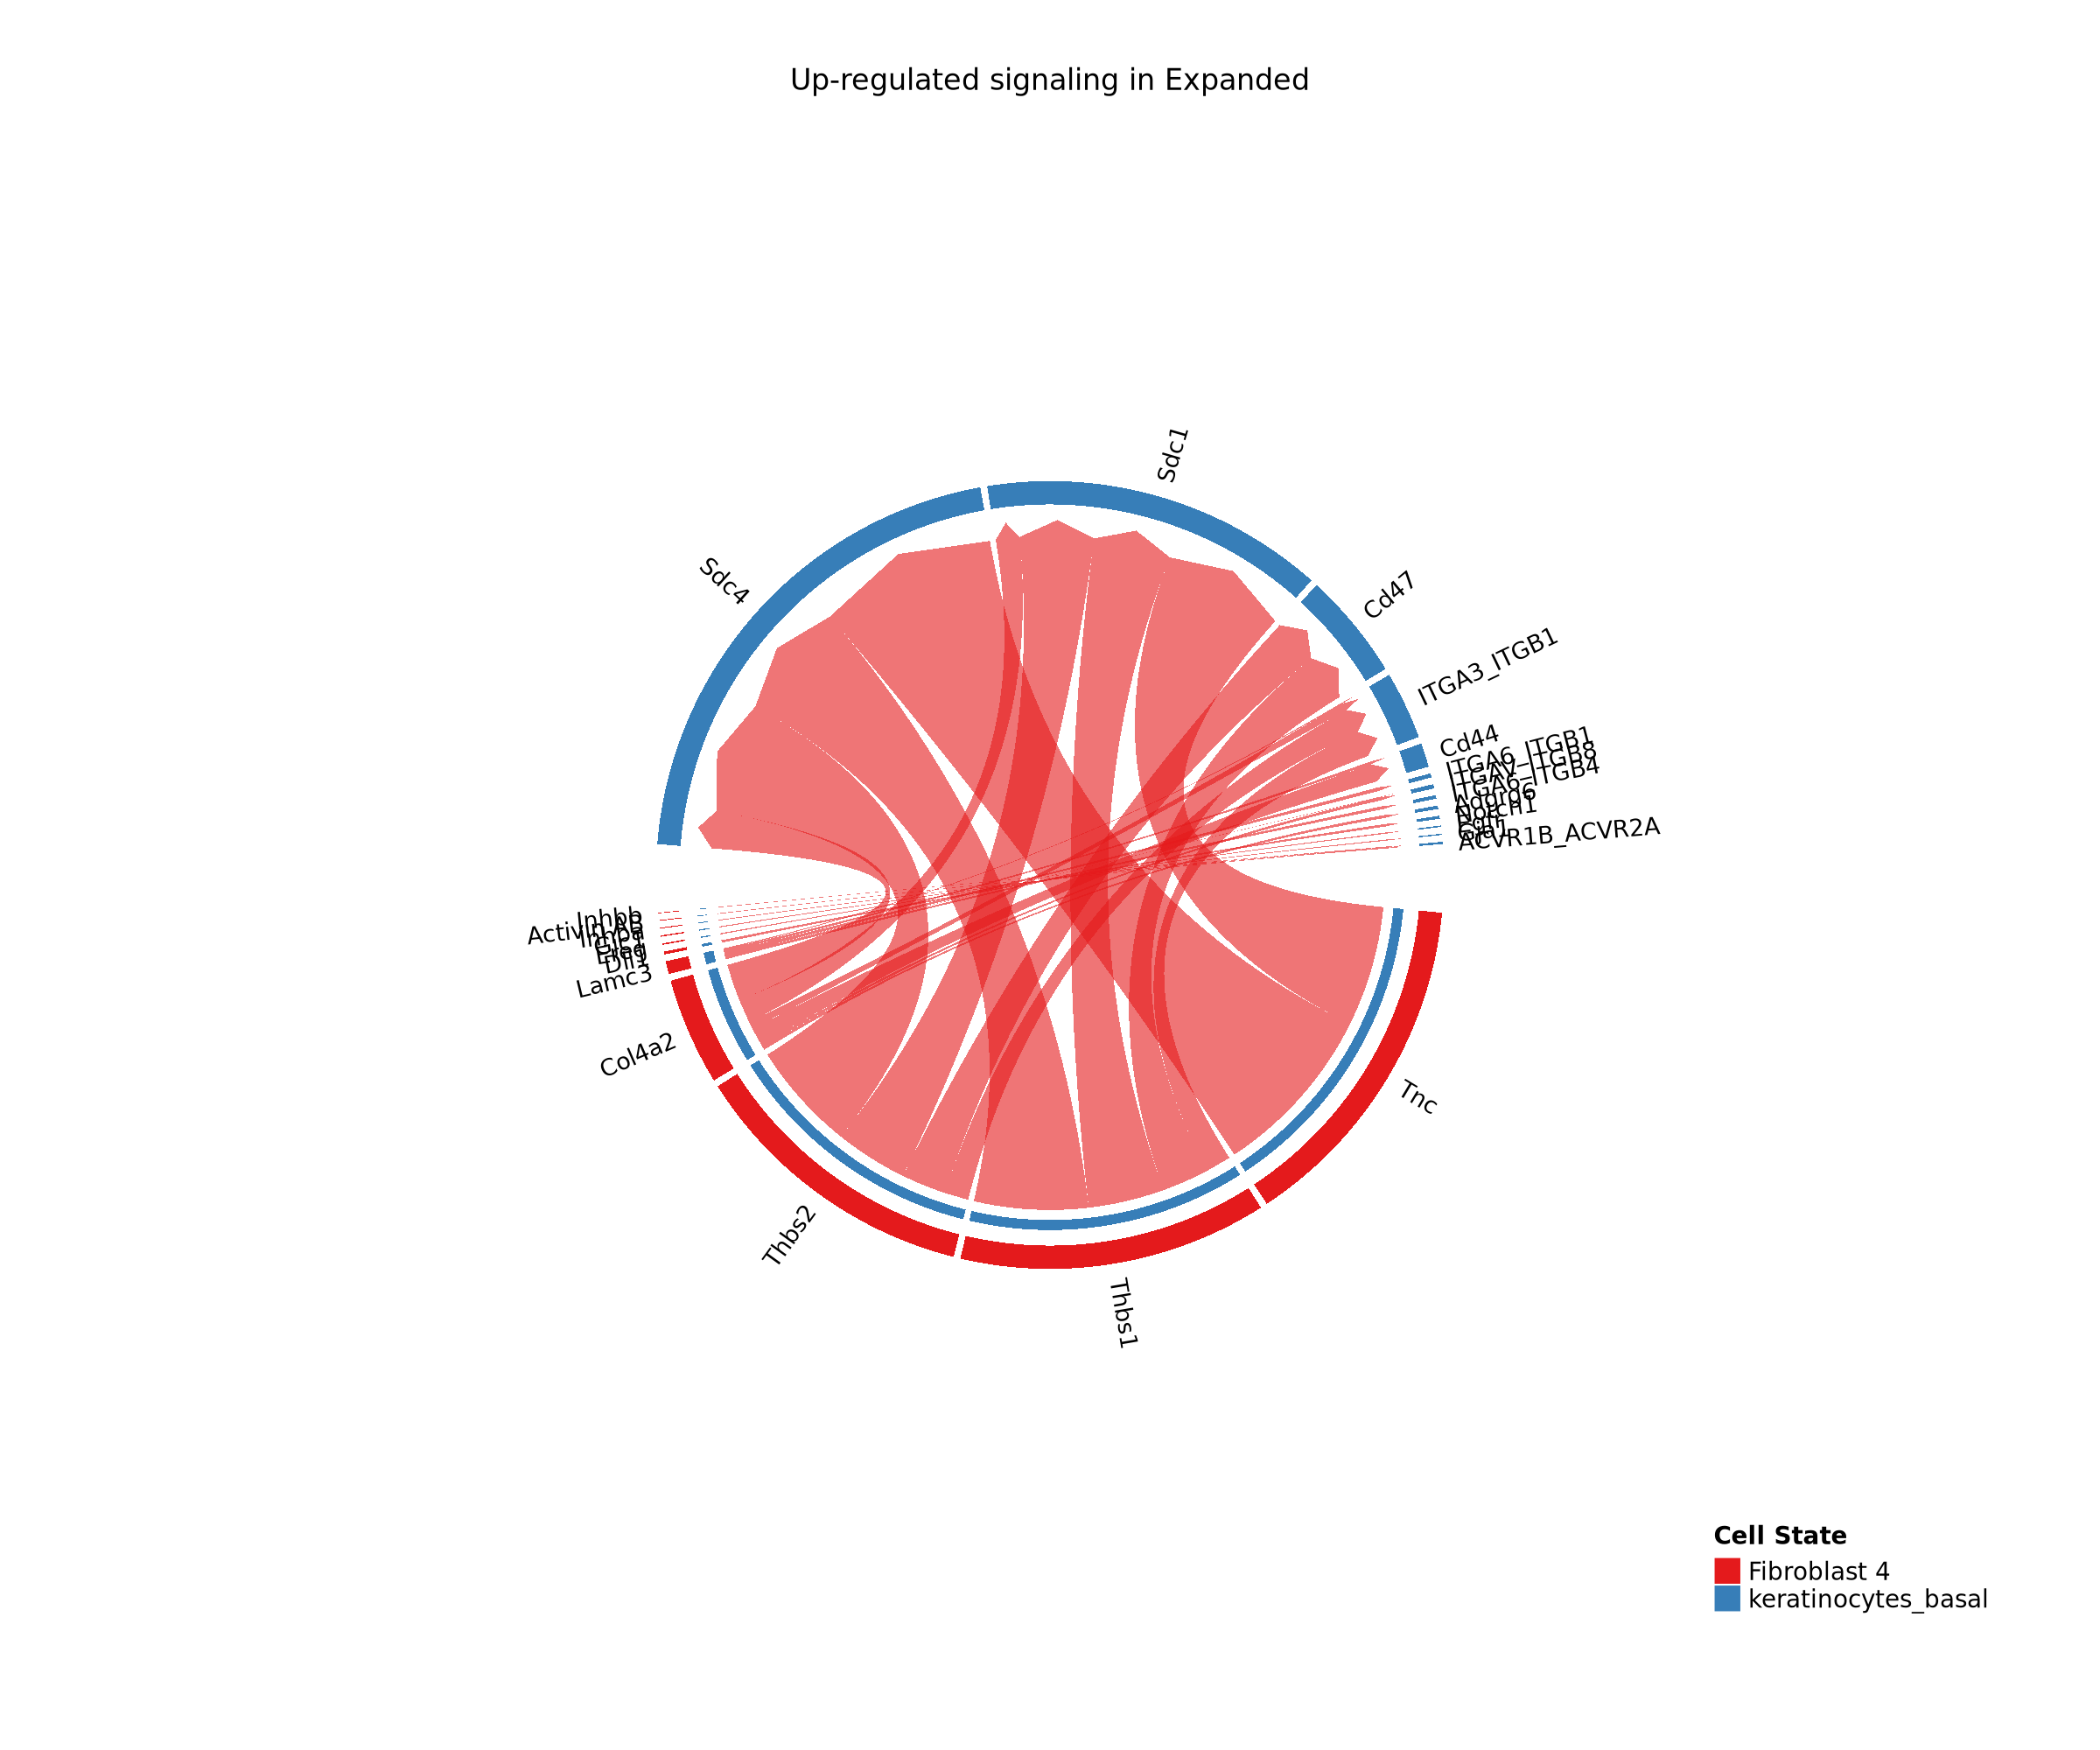

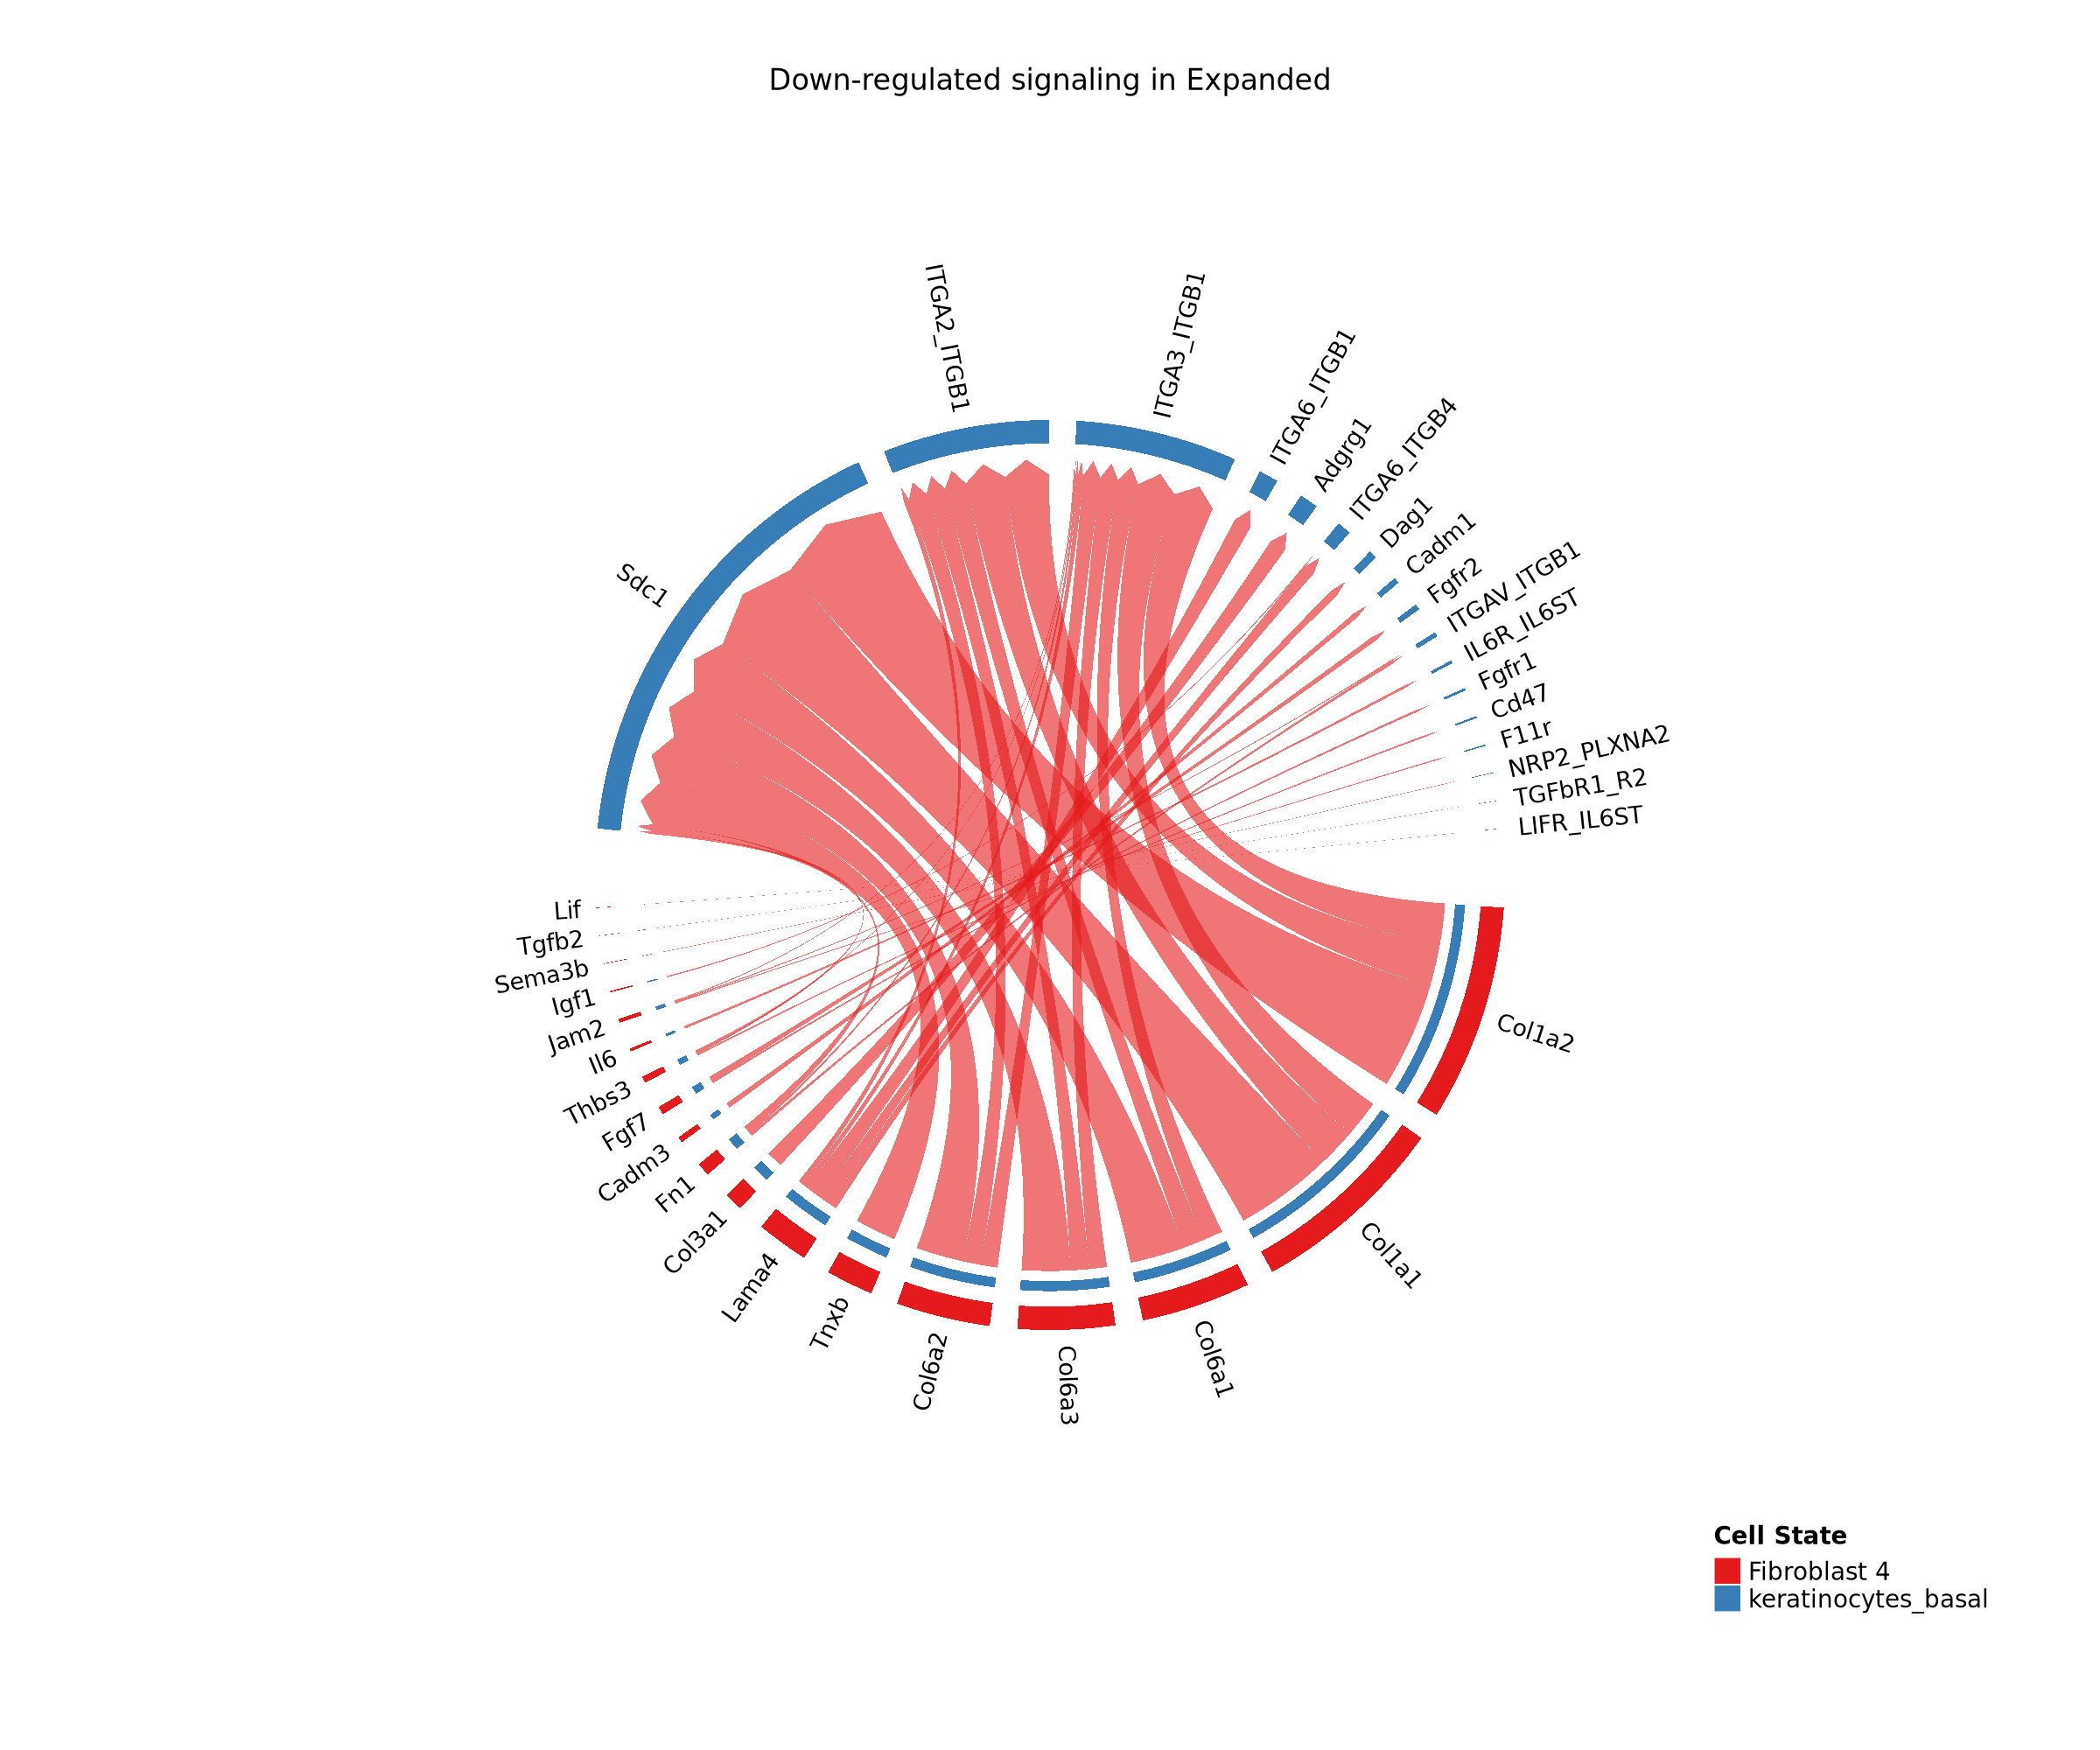

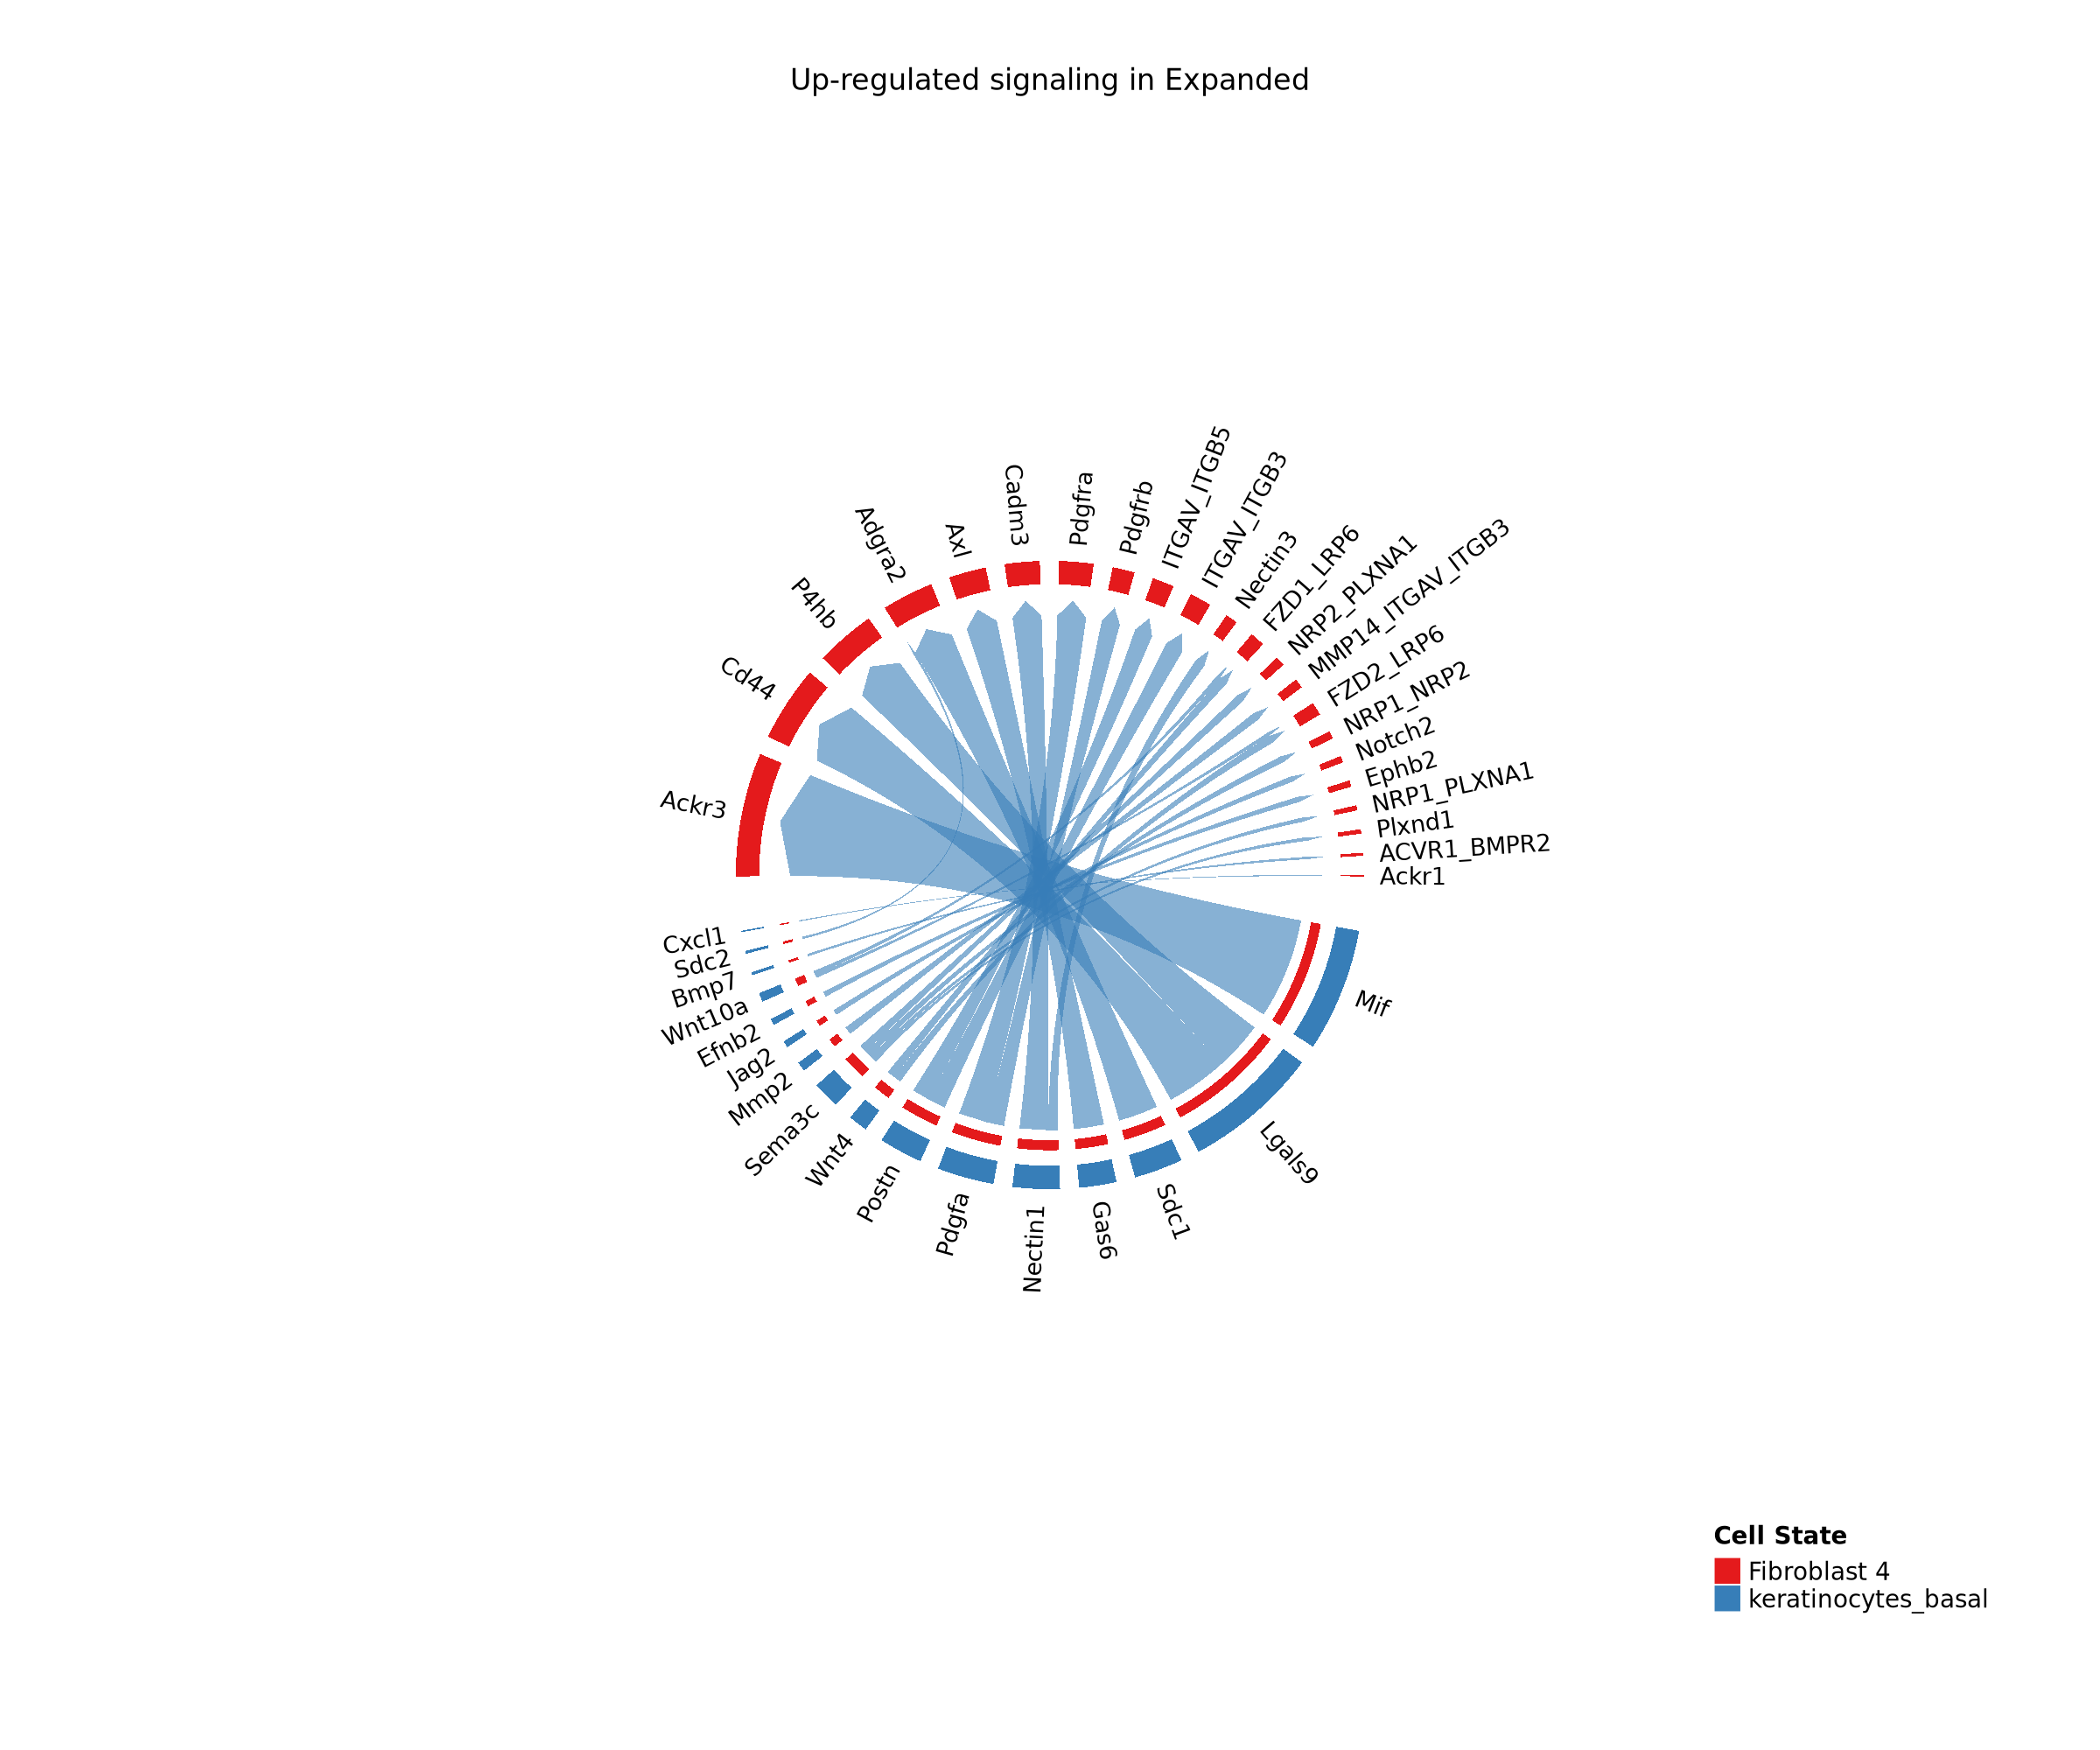

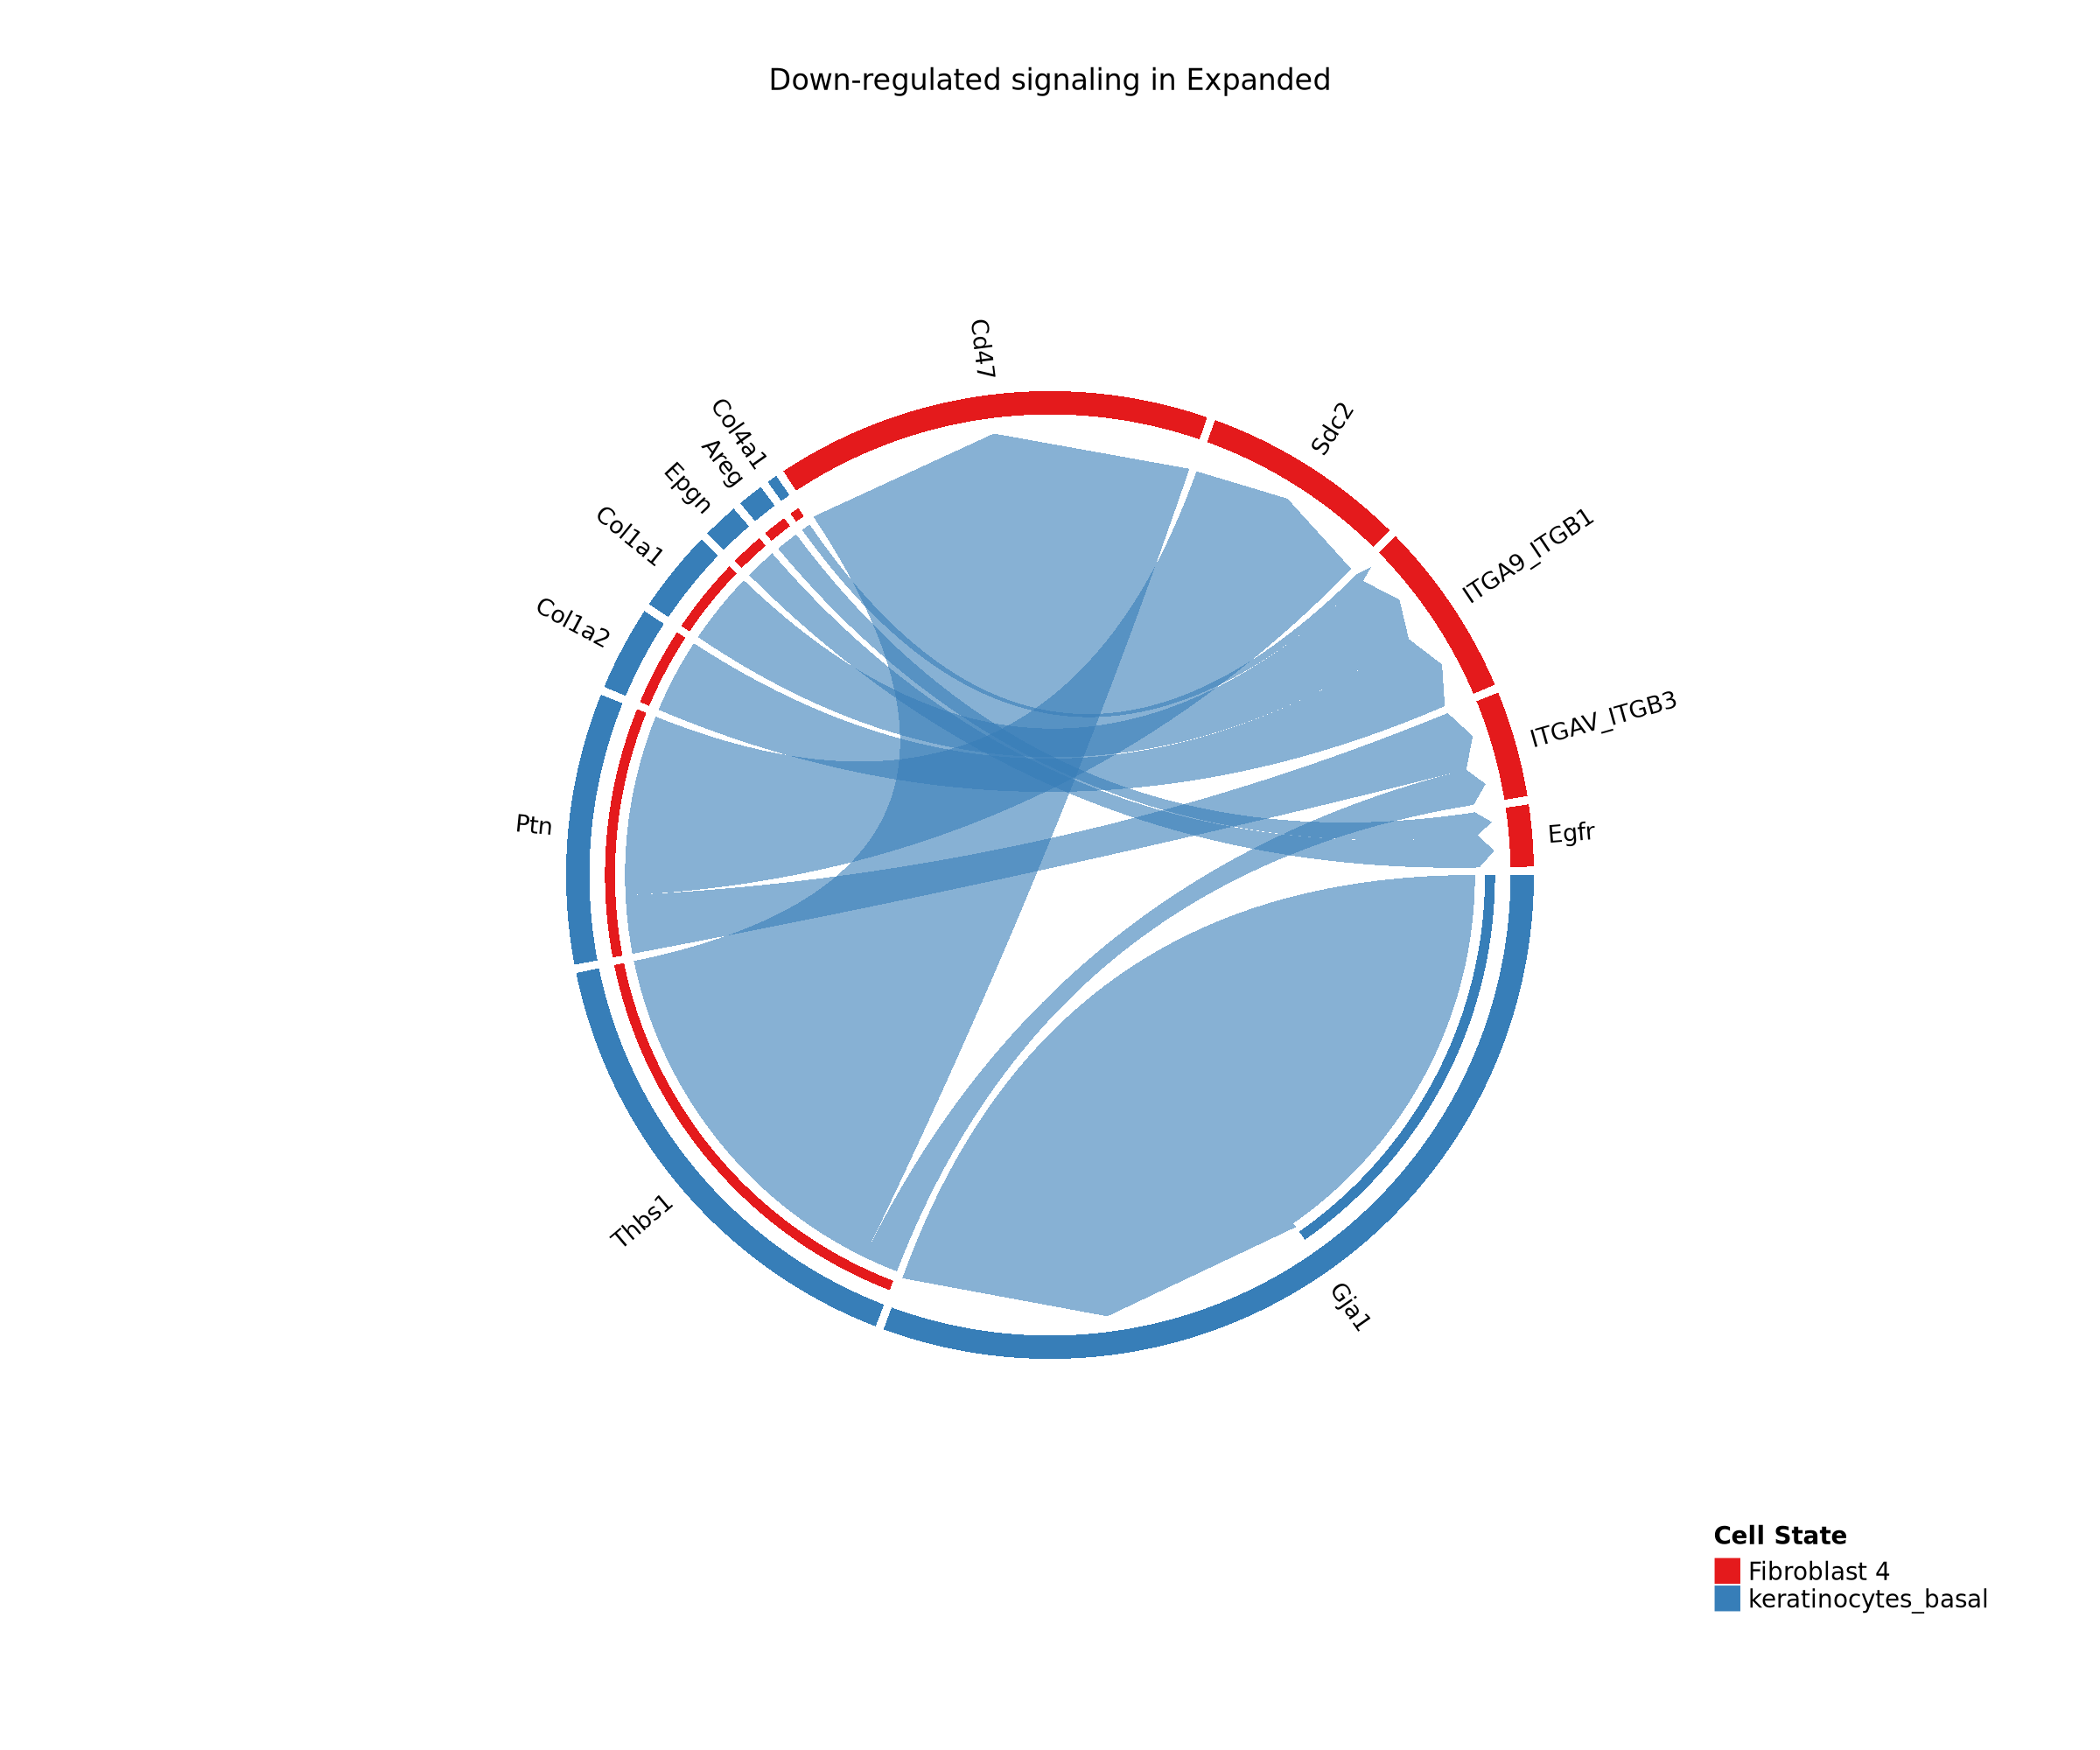

In [6]:
options(repr.plot.width = 12, repr.plot.height = 10, repr.plot.res = 200)
par(bg = "white")

# D1: Upregulated signaling in Expanded (Fibroblast 4 -> keratinocytes_basal)
D1 <- netVisual_chord_gene(
  object.list[[2]],
  sources.use = "Fibroblast 4",
  targets.use = "keratinocytes_basal",
  slot.name   = "net",
  net         = net.up,
  # lab.cex     = 0.8,
  # small.gap   = 20,
  title.name  = paste0("Up-regulated signaling in ", names(object.list)[2])
)

# D2: Downregulated signaling in Expanded (Fibroblast 4 -> keratinocytes_basal)
D2 <- netVisual_chord_gene(
  object.list[[1]],
  sources.use = "Fibroblast 4",
  targets.use = "keratinocytes_basal",
  slot.name   = "net",
  net         = net.down,
  lab.cex     = 0.8,
  small.gap   = 3.5,
  title.name  = paste0("Down-regulated signaling in ", names(object.list)[2])
)

# D3: Upregulated signaling in Expanded (keratinocytes_basal -> Fibroblast 4)
D3 <- netVisual_chord_gene(
  object.list[[2]],
  targets.use = "Fibroblast 4",
  sources.use = "keratinocytes_basal",
  slot.name   = "net",
  net         = net.up,
  lab.cex     = 0.8,
  small.gap   = 3.5,
  title.name  = paste0("Up-regulated signaling in ", names(object.list)[2])
)

# D4: Downregulated signaling in Expanded (keratinocytes_basal -> Fibroblast 4)
D4 <- netVisual_chord_gene(
  object.list[[1]],
  targets.use = "Fibroblast 4",
  sources.use = "keratinocytes_basal",
  slot.name   = "net",
  net         = net.down,
  lab.cex     = 0.8,
  small.gap   = 3.5,
  title.name  = paste0("Down-regulated signaling in ", names(object.list)[2])
)

# Save all four figures
# output_dir <- "~/stg_00077/projects/Ceyhun-sideprojects/skin_expansion/revision_figures"
# dir.create(output_dir, showWarnings = FALSE, recursive = TRUE)

# svg(file.path(output_dir, "Upregulated_signaling_in_Expanded.svg"), width = 12, height = 10)
# print(D1)
# dev.off()

# svg(file.path(output_dir, "Downregulated_signaling_in_Expanded.svg"), width = 12, height = 10)
# print(D2)
# dev.off()

# svg(file.path(output_dir, "Upregulated_signaling_in_Basal_to_Fibroblasts.svg"), width = 12, height = 10)
# print(D3)
# dev.off()

# svg(file.path(output_dir, "Downregulated_signaling_in_Basal_to_Fibroblasts.svg"), width = 12, height = 10)
# print(D4)
# dev.off()

# message("All 4 SVGs saved to: ", output_dir)